In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_recall_fscore_support,classification_report,confusion_matrix)

from datasets import Dataset
from transformers import (AutoTokenizer,AutoModelForSequenceClassification,TrainingArguments,Trainer)

In [ ]:
review = pd.read_csv("/content/zepto_reviews_raw.csv")

In [ ]:
print("Shape:", review.shape)
print(review.head(10))
print(review.columns.tolist())

Shape: (8240, 10)
   review_id    order_id user_id  product_id  \
0  RV0001920  ZPO0027335  U00219          46   
1  RV0004656  ZPO0066472  U02245          27   
2  RV0001840  ZPO0071302  U02749          79   
3  RV0004878  ZPO0078797  U02186          81   
4  RV0003821  ZPO0017795  U02873          83   
5  RV0007195  ZPO0073757  U01183          26   
6  RV0006512  ZPO0022818  U01783          35   
7  RV0005098  ZPO0007937  U02260           4   
8  RV0003468  ZPO0004183  U02150          52   
9  RV0001596  ZPO0062944  U00354          94   

                                         review_text rating sentiment  \
0  seriously items were packed neatly with proper...    4.0  positive   
1  seriously support agent was useless and kept r...    1.0  negative   
2  guys advertised offer was not applied to my or...    NaN  negative   
3  Coca Cola Coca Cola expiry date already over, ...    2.0  negative   
4  honestly order got cancelled automatically wit...    1.0  negative   
5         the G

#Data Cleaning

In [ ]:
review.duplicated().sum()

np.int64(110)

In [ ]:
review.drop_duplicates(inplace=True)
review.shape

(8130, 10)

In [ ]:
review.duplicated(subset=["review_id"]).sum()

np.int64(50)

In [ ]:
review.drop_duplicates(subset=["review_id"],inplace=True)
review.shape

(8080, 10)

In [ ]:
review.dtypes

,0
review_id,object
order_id,object
user_id,object
product_id,int64
review_text,object
rating,object
sentiment,object
topic,object
review_date,object
language,object


In [ ]:
review['review_date'] = pd.to_datetime(review['review_date'], format='mixed', errors='coerce')

In [ ]:
# Keep only required columns
review = review[[ "review_id","order_id","user_id","product_id","review_text","rating","sentiment","topic","review_date","language"]].copy()

In [ ]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML entities
    text = re.sub(r"&nbsp;", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Convert multiple spaces to one
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    # Lowercase
    text = text.lower()

    return text


review["review_text"] = review["review_text"].apply(clean_text)

In [ ]:
review = review[review["review_text"] != ""].copy()

In [ ]:
review = review.drop_duplicates(
    subset=["review_text"]
).reset_index(drop=True)

print("Shape after removing duplicate texts:", review.shape)

Shape after removing duplicate texts: (6788, 10)


In [ ]:
review["sentiment"] = (review["sentiment"].astype(str).str.strip().str.lower())

review["sentiment"] = review["sentiment"].replace({
    "pos": "positive",
    "neg": "negative",
    "neu": "neutral"
})

In [ ]:
review["sentiment"].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [ ]:
review["sentiment"].value_counts()

,count
sentiment,
negative,3522
positive,2285
neutral,981


In [ ]:
review["topic"] = (review["topic"].astype(str).str.strip().str.lower())

In [ ]:
topic_list = ["product","delivery","customer_support","order","payment","app","website","refund","membership","offers","inventory",
              "packaging","pricing","others"]

In [ ]:
review = review[review["topic"].isin(topic_list)].copy()

In [ ]:
print(review["topic"].value_counts())

topic
product             1447
delivery            1208
packaging            647
order                534
pricing              465
refund               457
app                  441
customer_support     415
inventory            322
offers               261
payment              232
others                95
membership            83
website               63
Name: count, dtype: int64


In [ ]:
review['rating'].value_counts()

,count
rating,
1.0,1823
5.0,1208
3.0,1119
2.0,1117
4.0,957
1 stars,32
1,29
5 stars,27
3 stars,26


In [ ]:
# Convert values like "5 stars" to 5
review["rating"] = (
    review["rating"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Change invalid rating 7 to 5
review["rating"] = review["rating"].replace(7.0, 5.0)

# Remove rating 0 because it is outside the 1–5 scale
review= review[review["rating"].between(1, 5)].copy()

# Check the result
print(review["rating"].value_counts().sort_index())

rating
1.0    1884
2.0    1162
3.0    1163
4.0     988
5.0    1275
Name: count, dtype: int64


In [ ]:
review.head(10)

,review_id,order_id,user_id,product_id,review_text,rating,sentiment,topic,review_date,language
0,RV0001920,ZPO0027335,U00219,46,seriously items were packed neatly with proper...,4.0,positive,packaging,2026-04-13,english
1,RV0004656,ZPO0066472,U02245,27,seriously support agent was useless and kept r...,1.0,negative,customer_support,2026-03-25,english
3,RV0004878,ZPO0078797,U02186,81,"coca cola coca cola expiry date already over, ...",2.0,negative,product,2026-01-27,tanglish
4,RV0003821,ZPO0017795,U02873,83,honestly order got cancelled automatically wit...,1.0,negative,order,2026-03-20,english
5,RV0007195,ZPO0073757,U01183,26,the grapes green was stale and smelled bad,1.0,negative,product,2026-02-15,english
6,RV0006512,ZPO0022818,U01783,35,seriously the box was torn and items fell out,2.0,negative,packaging,2026-04-24,english
7,RV0005098,ZPO0007937,U02260,4,"honestly love the new app design, very smooth",3.0,positive,app,2026-05-18,english
9,RV0001596,ZPO0062944,U00354,94,"recived the mccain aloo tikki, average qality",3.0,neutral,product,2026-05-13,english
10,RV0006012,ZPO0033420,U00222,28,"honestly papaya super quality, family loved it...",5.0,positive,product,2026-06-20,english
12,RV0004626,ZPO0002137,U01225,57,hello handling fee and platform fee on top of ...,4.0,negative,pricing,2026-05-18,english


In [ ]:
review.isnull().sum()

,0
review_id,0
order_id,0
user_id,0
product_id,0
review_text,0
rating,0
sentiment,0
topic,0
review_date,0
language,0


In [ ]:
print("Final dataset shape:", review.shape)

print("\nSentiment:")
print(review["sentiment"].value_counts())

print("\nTopic:")
print(review["topic"].value_counts())

print("\nMissing values:")
print(review[["review_text", "sentiment", "topic"]].isnull().sum())

#step 8

Final dataset shape: (6472, 10)

Sentiment:
sentiment
negative    3364
positive    2166
neutral      942
Name: count, dtype: int64

Topic:
topic
product             1410
delivery            1174
packaging            629
order                518
pricing              455
refund               438
app                  430
customer_support     396
inventory            313
offers               249
payment              226
others                90
membership            82
website               62
Name: count, dtype: int64

Missing values:
review_text    0
sentiment      0
topic          0
dtype: int64


In [ ]:
sentiment_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

review["sentiment_label"] = review["sentiment"].map(sentiment_mapping)

In [ ]:
topic_mapping = {
    topic: index
    for index, topic in enumerate(topic_list)
}

review["topic_label"] = review["topic"].map(
    topic_mapping
)

In [ ]:
print(review[["review_text", "sentiment", "sentiment_label", "topic", "topic_label"]].head(10))

                                          review_text sentiment  \
0   seriously items were packed neatly with proper...  positive   
1   seriously support agent was useless and kept r...  negative   
3   coca cola coca cola expiry date already over, ...  negative   
4   honestly order got cancelled automatically wit...  negative   
5          the grapes green was stale and smelled bad  negative   
6       seriously the box was torn and items fell out  negative   
7       honestly love the new app design, very smooth  positive   
8       recived the mccain aloo tikki, average qality   neutral   
9   honestly papaya super quality, family loved it...  positive   
11  hello handling fee and platform fee on top of ...  negative   

    sentiment_label             topic  topic_label  
0                 2         packaging           11  
1                 0  customer_support            2  
3                 0           product            0  
4                 0             order            3

In [ ]:
print("Duplicate review texts:", review["review_text"].duplicated().sum())

Duplicate review texts: 0


In [ ]:
#read and write the review file

In [ ]:


review = pd.read_csv("/content/zepto_reviews_raw.csv")

print("Original shape:", review.shape)

Original shape: (8240, 10)


In [ ]:
review = pd.read_csv("/content/cleaned_zepto_review_dataset.csv")

print(review.head())

   review_id    order_id user_id  product_id  \
0  RV0001920  ZPO0027335  U00219          46   
1  RV0004656  ZPO0066472  U02245          27   
2  RV0004878  ZPO0078797  U02186          81   
3  RV0003821  ZPO0017795  U02873          83   
4  RV0007195  ZPO0073757  U01183          26   

                                         review_text  rating sentiment  \
0  seriously items were packed neatly with proper...     4.0  positive   
1  seriously support agent was useless and kept r...     1.0  negative   
2  coca cola coca cola expiry date already over, ...     2.0  negative   
3  honestly order got cancelled automatically wit...     1.0  negative   
4         the grapes green was stale and smelled bad     1.0  negative   

              topic review_date  language  sentiment_label  topic_label  
0         packaging  2026-04-13   english                2           11  
1  customer_support  2026-03-25   english                0            2  
2           product  2026-01-27  tanglish   

In [ ]:
# Save the cleaned dataset
review.to_csv(
    "/content/Reviews_Cleaned_Final.csv",
    index=False
)

print("File saved successfully!")
print("Shape:", review.shape)

File saved successfully!
Shape: (6503, 12)


In [ ]:
import pandas as pd

review = pd.read_csv("/content/Reviews_Cleaned_Final.csv")

print("Review file loaded successfully!")
print("Shape:", review.shape)
print("Columns:", review.columns.tolist())

Review file loaded successfully!
Shape: (6503, 12)
Columns: ['review_id', 'order_id', 'user_id', 'product_id', 'review_text', 'rating', 'sentiment', 'topic', 'review_date', 'language', 'sentiment_label', 'topic_label']


In [ ]:
import pandas as pd

review = pd.read_csv("/content/Reviews_Cleaned_Final.csv")

print("Review file loaded successfully!")
print("Shape:", review.shape)
print("Columns:", review.columns.tolist())

Review file loaded successfully!
Shape: (6503, 12)
Columns: ['review_id', 'order_id', 'user_id', 'product_id', 'review_text', 'rating', 'sentiment', 'topic', 'review_date', 'language', 'sentiment_label', 'topic_label']


#Model preparation-sentiment_label

In [ ]:
review["sentiment"] = (
    review["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

review["sentiment"] = review["sentiment"].replace({
    "pos": "positive",
    "neg": "negative",
    "neu": "neutral"
})

review = review[
    review["sentiment"].isin(["positive", "neutral", "negative"])
].copy()

sentiment_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

review["sentiment_label"] = review["sentiment"].map(sentiment_mapping)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    review,
    test_size=0.20,
    random_state=42,
    stratify=review["sentiment_label"]
)

In [ ]:

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 5202
Test: 1301


In [ ]:
train_texts = set(train_df["review_text"])
test_texts = set(test_df["review_text"])

overlap = train_texts.intersection(test_texts)

print("Duplicate texts between train and test:", len(overlap))

Duplicate texts between train and test: 0


In [ ]:
print("Shape after removing duplicate texts:", review.shape)
print("Duplicate texts between train and test:", len(overlap))

Shape after removing duplicate texts: (6503, 12)
Duplicate texts between train and test: 0


In [ ]:
from datasets import Dataset

sent_train = Dataset.from_pandas(
    train_df[
        ["review_text", "sentiment_label"]
    ].rename(
        columns={"sentiment_label": "labels"}
    ),
    preserve_index=False
)

sent_test = Dataset.from_pandas(
    test_df[
        ["review_text", "sentiment_label"]
    ].rename(
        columns={"sentiment_label": "labels"}
    ),
    preserve_index=False
)

print(sent_train)
print(sent_test)

Dataset({
    features: ['review_text', 'labels'],
    num_rows: 5202
})
Dataset({
    features: ['review_text', 'labels'],
    num_rows: 1301
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["review_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

sent_train_tokenized = sent_train.map(
    tokenize_function,
    batched=True
).remove_columns(["review_text"])

sent_test_tokenized = sent_test.map(
    tokenize_function,
    batched=True
).remove_columns(["review_text"])

print(sent_train_tokenized)
print(sent_test_tokenized)

Map:   0%|          | 0/5202 [00:00<?, ? examples/s]

Map:   0%|          | 0/1301 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5202
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1301
})


In [ ]:
print(sent_train["labels"][:10])
print(set(sent_train["labels"]))

[2, 2, 0, 2, 1, 0, 2, 0, 1, 2]
{0, 1, 2}


In [ ]:
sent_train = sent_train.remove_columns(["review_text"])
sent_test = sent_test.remove_columns(["review_text"])

In [ ]:
print(sent_train)
print(sent_test)

Dataset({
    features: ['labels'],
    num_rows: 5202
})
Dataset({
    features: ['labels'],
    num_rows: 1301
})


In [ ]:
from transformers import AutoModelForSequenceClassification

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}
label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(label2id)
print(id2label)

{'Negative': 0, 'Neutral': 1, 'Positive': 2}
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./sentiment_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
#create trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=sent_train_tokenized,
    eval_dataset=sent_test_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.004407,0.998463,0.998468,0.998463,0.998462
2,0.123940,0.000888,1.000000,1.000000,1.000000,1.000000
3,0.123940,0.000527,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=978, training_loss=0.0641309413563742, metrics={'train_runtime': 204.7896, 'train_samples_per_second': 76.205, 'train_steps_per_second': 4.776, 'total_flos': 516830772635136.0, 'train_loss': 0.0641309413563742, 'epoch': 3.0})

In [ ]:
#evaluation
eval_results = trainer.evaluate()

print(eval_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.123940,0.000888,3,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 0.0008875616476871073, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0}


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

predictions = trainer.predict(sent_test_tokenized)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

actual_labels = predictions.label_ids

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       677
     Neutral       1.00      1.00      1.00       189
    Positive       1.00      1.00      1.00       435

    accuracy                           1.00      1301
   macro avg       1.00      1.00      1.00      1301
weighted avg       1.00      1.00      1.00      1301



In [ ]:
print("Current test dataset:", len(sent_test_tokenized))
print("Prediction count:", len(predictions.label_ids))

Current test dataset: 1301
Prediction count: 1301


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    review,
    test_size=0.20,
    random_state=42,
    stratify=review["sentiment_label"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 5202
Test: 1301


In [ ]:
print("Current reviews shape:", review.shape)
print("Duplicate review texts:", review["review_text"].duplicated().sum())

Current reviews shape: (6503, 12)
Duplicate review texts: 0


In [ ]:
# Remove duplicate review texts
review = review.drop_duplicates(
    subset=["review_text"],
    keep="first"
).reset_index(drop=True)

print("Shape after removing duplicates:", review.shape)
print("Duplicate review texts:", review["review_text"].duplicated().sum())

Shape after removing duplicates: (6503, 12)
Duplicate review texts: 0


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    review,
    test_size=0.20,
    random_state=42,
    stratify=review["sentiment_label"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 5202
Test: 1301


In [ ]:
train_texts = set(train_df["review_text"])
test_texts = set(test_df["review_text"])

overlap = train_texts.intersection(test_texts)

print("Duplicate texts between train and test:", len(overlap))

Duplicate texts between train and test: 0


In [ ]:
import os

model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT"

os.makedirs(model_path, exist_ok=True)

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print("Sentiment model saved successfully!")
print("Location:", model_path)

##load the sentiment_label model load

In [ ]:
import os

model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT"

os.makedirs(model_path, exist_ok=True)

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print("Sentiment model saved successfully!")
print("Location:", model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Sentiment model saved successfully!
Location: /content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT


In [ ]:
from google.colab import drive
import os
import shutil

mountpoint = "/content/drive"

# Ensure the mount point is clean before attempting to mount
if os.path.exists(mountpoint):
    if os.path.ismount(mountpoint):
        # If it's an active mount, try to unmount it first
        print(f"Unmounting existing drive at {mountpoint}...")
        try:
            drive.flush_and_unmount()
            print("Drive unmounted successfully.")
        except Exception as e:
            print(f"Warning: Failed to unmount existing drive: {e}")
    elif os.path.isdir(mountpoint) and os.listdir(mountpoint):
        # If it's a directory that's not a mount point but contains files,
        # remove its contents. This is the scenario that causes the specific ValueError.
        print(f"Mountpoint {mountpoint} contains files but is not mounted. Clearing contents...")
        try:
            shutil.rmtree(mountpoint)
            os.makedirs(mountpoint) # Recreate the empty directory
            print("Directory cleared successfully.")
        except Exception as e:
            print(f"Error clearing mountpoint directory: {e}")
else:
    # If the directory doesn't exist, create it to ensure a clean state
    os.makedirs(mountpoint, exist_ok=True)
    print(f"Created empty mountpoint directory {mountpoint}.")

# Now attempt to mount the drive
drive.mount(mountpoint, force_remount=True)

In [ ]:


print(os.listdir("/content/drive/MyDrive"))

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [ ]:



project_path = "/content/drive/MyDrive/Smart_Delivery_Project"

os.makedirs(project_path, exist_ok=True)

print("Project folder created:")
print(project_path)

In [ ]:
model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT"

os.makedirs(model_path, exist_ok=True)

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print("Sentiment model saved successfully!")
print("Saved location:")
print(model_path)

In [ ]:


print("Files saved in model folder:")

for file in os.listdir(model_path):
    print(file)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#reload command
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("Model loaded successfully!")

##Topic Classification model

In [ ]:
from sklearn.model_selection import train_test_split

topic_train_df, topic_test_df = train_test_split(
    review,
    test_size=0.20,
    random_state=42,
    stratify=review["topic_label"]
)

print("Topic Train:", len(topic_train_df))
print("Topic Test:", len(topic_test_df))

print("\nTopic Train distribution:")
print(topic_train_df["topic_label"].value_counts().sort_index())

print("\nTopic Test distribution:")
print(topic_test_df["topic_label"].value_counts().sort_index())

Topic Train: 5202
Topic Test: 1301

Topic Train distribution:
topic_label
0     1128
1      942
2      319
3      419
4      181
5      346
6       50
7      353
8       66
9      202
10     251
11     506
12     367
13      72
Name: count, dtype: int64

Topic Test distribution:
topic_label
0     282
1     235
2      80
3     105
4      45
5      87
6      12
7      88
8      16
9      51
10     63
11    127
12     92
13     18
Name: count, dtype: int64


In [ ]:
#Create Topic datasets
from datasets import Dataset

topic_train = Dataset.from_pandas(topic_train_df[["review_text", "topic_label"]].rename(columns={"topic_label": "labels"}), preserve_index=False)

topic_test = Dataset.from_pandas(topic_test_df[["review_text", "topic_label"]].rename(columns={"topic_label": "labels"}), preserve_index=False)

print("Topic Train:", len(topic_train))
print("Topic Test:", len(topic_test))

Topic Train: 5202
Topic Test: 1301


In [ ]:
print("Train topics:", topic_train["labels"][:10]); print("Unique topics:", sorted(set(topic_train["labels"])))

Train topics: [12, 3, 0, 2, 0, 4, 1, 12, 0, 0]
Unique topics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_topic(batch):
    return tokenizer(
        batch["review_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

topic_train = topic_train.map(tokenize_topic, batched=True)
topic_test = topic_test.map(tokenize_topic, batched=True)

print("Topic tokenization completed!")

Map:   0%|          | 0/5202 [00:00<?, ? examples/s]

Map:   0%|          | 0/1301 [00:00<?, ? examples/s]

Topic tokenization completed!


In [ ]:
#Load the 14-class Topic Model
from transformers import AutoModelForSequenceClassification

topic_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=14
)

print("14-class Topic model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


14-class Topic model loaded successfully!


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Smart_Delivery_Project/Topic_DistilBERT_Checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none"
)

print("Training arguments created successfully!")

Training arguments created successfully!


In [ ]:

def compute_topic_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        p.label_ids,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(p.label_ids, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Topic metrics function created successfully!")

Topic metrics function created successfully!


In [ ]:
from transformers import Trainer

topic_trainer = Trainer(
    model=topic_model,
    args=training_args,
    train_dataset=topic_train,
    eval_dataset=topic_test,
    processing_class=tokenizer,
    compute_metrics=compute_topic_metrics
)

print("Topic Trainer created successfully!")

Topic Trainer created successfully!


In [ ]:
topic_train_result = topic_trainer.train()

print("Topic model training completed!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.124089,0.061945,0.996925,0.996969,0.996925,0.996832
2,0.019253,0.014939,0.999231,0.999235,0.999231,0.999231
3,0.012708,0.011205,0.999231,0.999272,0.999231,0.999241


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Topic model training completed!


In [ ]:
topic_model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Topic_DistilBERT"

import os
os.makedirs(topic_model_path, exist_ok=True)

topic_trainer.save_model(topic_model_path)
tokenizer.save_pretrained(topic_model_path)

print("Topic model saved successfully!")
print("Saved location:", topic_model_path)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

topic_model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Topic_DistilBERT"

topic_tokenizer = AutoTokenizer.from_pretrained(topic_model_path)
topic_model_loaded = AutoModelForSequenceClassification.from_pretrained(topic_model_path)

print("Topic model loaded successfully!")
print("Number of topic classes:", topic_model_loaded.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Topic model loaded successfully!
Number of topic classes: 14


In [ ]:
#test the Topic model with one sample review
import torch

sample_review = "The delivery was very fast and the food arrived on time."

inputs = topic_tokenizer(
    sample_review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = topic_model_loaded(**inputs)

predicted_topic = torch.argmax(outputs.logits, dim=1).item()

print("Review:", sample_review)
print("Predicted Topic Label:", predicted_topic)

Review: The delivery was very fast and the food arrived on time.
Predicted Topic Label: 1


In [ ]:
print("Topic Label Mapping:")

topic_mapping = (
    review[["topic_label"]]
    .drop_duplicates()
    .sort_values("topic_label")
    .reset_index(drop=True)
)

print(topic_mapping.to_string(index=False))

Topic Label Mapping:
 topic_label
           0
           1
           2
           3
           4
           5
           6
           7
           8
           9
          10
          11
          12
          13


In [ ]:
for topic in sorted(review["topic_label"].unique()):
    print("\n" + "=" * 60)
    print("TOPIC LABEL:", topic)
    print("=" * 60)

    samples = review[review["topic_label"] == topic]["review_text"].head(5)

    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")


TOPIC LABEL: 0
1. coca cola coca cola expiry date already over, how can you send this do something about it !!
2. the grapes green was stale and smelled bad
3. recived the mccain aloo tikki, average qality
4. honestly papaya super quality, family loved it !!!!
5. hi worst britannia good day cashew i have received, totally rotten

TOPIC LABEL: 1
1. honestly rider was rude and did not even apologise for being late pls look into this
2. team reached before the promised time, impressed
3. guys super fast delivery even in the rain !!
4. seriously delevery was ok, slightly late but fine
5. hi delivered in 8 minutes, very fast kindly resolve ⭐

TOPIC LABEL: 2
1. seriously support agent was useless and kept repeating the same thing visit for more
2. support agent understood the issue and fixed it fast :( 🔥
3. as usual supprt team resolved my issue within minutes
4. honestly support team resolved my issue within minuts
5. seriously customer care responded, waiting for update

TOPIC LABEL: 3
1.

In [ ]:
topic_names = {
    0: "Product Quality",
    1: "Delivery Experience",
    2: "Customer Support",
    3: "Order Issues",
    4: "Payment Issues",
    5: "App Experience",
    6: "Website Experience",
    7: "Refund Issues",
    8: "Membership",
    9: "Coupons & Offers",
    10: "Product Availability",
    11: "Packaging",
    12: "Pricing & Fees",
    13: "Overall Experience"
}

print("Topic mapping created successfully!")

for label, name in topic_names.items():
    print(f"{label}: {name}")

Topic mapping created successfully!
0: Product Quality
1: Delivery Experience
2: Customer Support
3: Order Issues
4: Payment Issues
5: App Experience
6: Website Experience
7: Refund Issues
8: Membership
9: Coupons & Offers
10: Product Availability
11: Packaging
12: Pricing & Fees
13: Overall Experience


In [ ]:


sample_review = "The delivery was very fast and the food arrived on time."

inputs = topic_tokenizer(
    sample_review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = topic_model_loaded(**inputs)

predicted_label = torch.argmax(outputs.logits, dim=1).item()
predicted_topic = topic_names[predicted_label]

print("Review:", sample_review)
print("Predicted Topic Label:", predicted_label)
print("Predicted Topic Name:", predicted_topic)

Review: The delivery was very fast and the food arrived on time.
Predicted Topic Label: 1
Predicted Topic Name: Delivery Experience


In [ ]:


sentiment_model_path = "/content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT"

sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_path)
sentiment_model_loaded = AutoModelForSequenceClassification.from_pretrained(
    sentiment_model_path
)

print("Sentiment model loaded successfully!")
print("Number of sentiment classes:", sentiment_model_loaded.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment model loaded successfully!
Number of sentiment classes: 3


In [ ]:
#combined Sentiment + Topic prediction


sentiment_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

def predict_review(review_text):

    # ---------------- SENTIMENT ----------------
    sentiment_inputs = sentiment_tokenizer(
        review_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        sentiment_output = sentiment_model_loaded(**sentiment_inputs)

    sentiment_label = torch.argmax(
        sentiment_output.logits, dim=1
    ).item()

    sentiment_name = sentiment_names[sentiment_label]

    # ---------------- TOPIC ----------------
    topic_inputs = topic_tokenizer(
        review_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        topic_output = topic_model_loaded(**topic_inputs)

    topic_label = torch.argmax(
        topic_output.logits, dim=1
    ).item()

    topic_name = topic_names[topic_label]

    # ---------------- RESULT ----------------
    return {
        "Review": review_text,
        "Sentiment Label": sentiment_label,
        "Sentiment": sentiment_name,
        "Topic Label": topic_label,
        "Topic": topic_name
    }

print("Combined prediction function created successfully!")

Combined prediction function created successfully!


In [ ]:
#Predicting one sample review
sample_review = "The delivery was very late and the rider was rude."

result = predict_review(sample_review)

for key, value in result.items():
    print(f"{key}: {value}")

Review: The delivery was very late and the rider was rude.
Sentiment Label: 0
Sentiment: Negative
Topic Label: 1
Topic: Delivery Experience


In [ ]:
#predicting all the class
test_reviews = [
    "The food was fresh and the quality was excellent.",
    "The delivery was slightly late but everything was fine.",
    "The payment failed and money was deducted from my account.",
    "The app is very slow and keeps freezing.",
    "The refund was processed quickly and the money came back."
]

for review_text in test_reviews:
    result = predict_review(review_text)

    print("=" * 70)
    print("Review:", result["Review"])
    print("Sentiment:", result["Sentiment"])
    print("Topic:", result["Topic"])

Review: The food was fresh and the quality was excellent.
Sentiment: Positive
Topic: Product Quality
Review: The delivery was slightly late but everything was fine.
Sentiment: Neutral
Topic: Delivery Experience
Review: The payment failed and money was deducted from my account.
Sentiment: Negative
Topic: Payment Issues
Review: The app is very slow and keeps freezing.
Sentiment: Negative
Topic: App Experience
Review: The refund was processed quickly and the money came back.
Sentiment: Positive
Topic: Refund Issues


In [ ]:
#save the combined prediction
import json
import os

nlp_config = {
    "sentiment_names": {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    },
    "topic_names": {
        0: "Product Quality",
        1: "Delivery Experience",
        2: "Customer Support",
        3: "Order Issues",
        4: "Payment Issues",
        5: "App Experience",
        6: "Website Experience",
        7: "Refund Issues",
        8: "Membership",
        9: "Coupons & Offers",
        10: "Product Availability",
        11: "Packaging",
        12: "Pricing & Fees",
        13: "Overall Experience"
    }
}

config_path = "/content/drive/MyDrive/Smart_Delivery_Project/nlp_config.json"

with open(config_path, "w") as f:
    json.dump(nlp_config, f, indent=4)

print("NLP configuration saved successfully!")
print("Saved location:", config_path)

NLP configuration saved successfully!
Saved location: /content/drive/MyDrive/Smart_Delivery_Project/nlp_config.json


In [ ]:
#verify the complete NLP files in Google Drive


base_path = "/content/drive/MyDrive/Smart_Delivery_Project"

required_paths = [
    "Final_Sentiment_DistilBERT",
    "Final_Topic_DistilBERT",
    "nlp_config.json"
]

print("Smart Delivery NLP files:")
print("-" * 50)

for item in required_paths:
    path = os.path.join(base_path, item)
    print(f"{item}: {'✓ Found' if os.path.exists(path) else '✗ Missing'}")

Smart Delivery NLP files:
--------------------------------------------------
Final_Sentiment_DistilBERT: ✓ Found
Final_Topic_DistilBERT: ✓ Found
nlp_config.json: ✓ Found


In [ ]:
#Downloading the NLP files from Google Drive
import shutil
import os

source = "/content/drive/MyDrive/Smart_Delivery_Project"
zip_path = "/content/Smart_Delivery_NLP"

shutil.make_archive(
    zip_path,
    "zip",
    source
)

print("NLP package created successfully!")
print("File:", zip_path + ".zip")

In [ ]:
from google.colab import files

files.download("/content/Smart_Delivery_NLP.zip")

######Model NLP Analytics.

Dataset Shape: (6503, 12)

Sentiment column values:
sentiment_label
0    3387
2    2173
1     943
Name: count, dtype: int64

SENTIMENT DISTRIBUTION

Total Reviews: 6503


,Sentiment,Review_Count,Percentage
0,Negative,3387,52.08
1,Neutral,943,14.50
2,Positive,2173,33.42


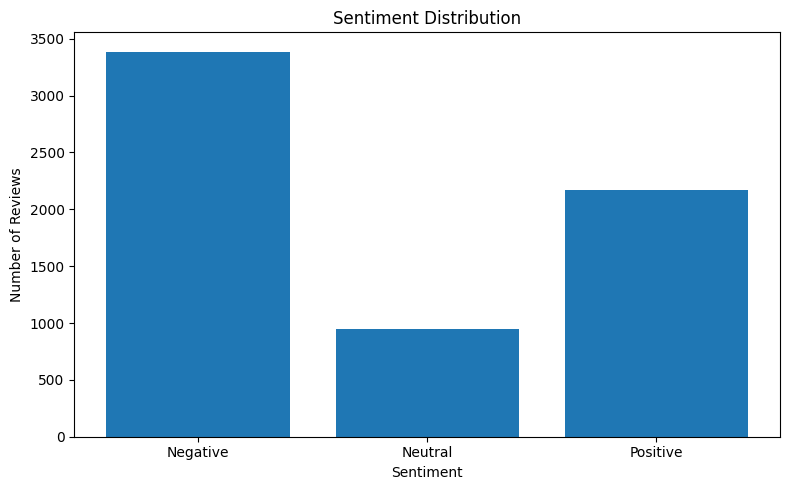

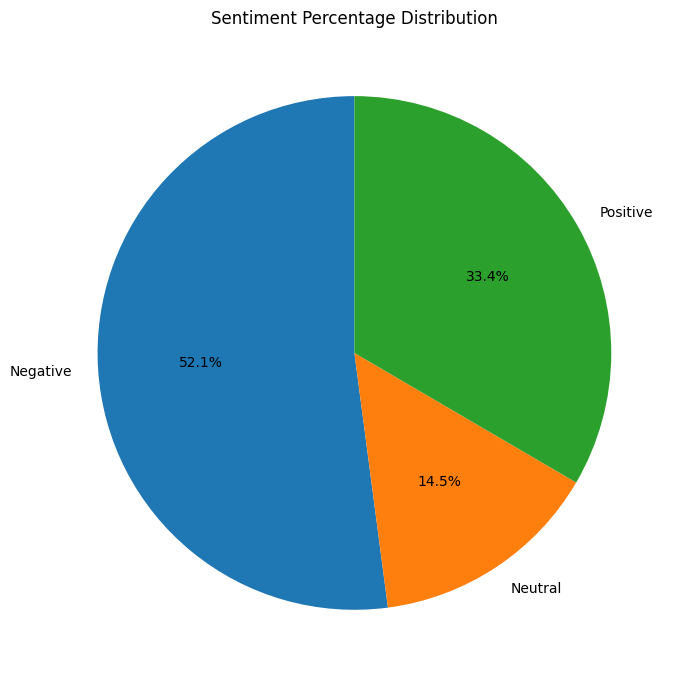


SENTIMENT SUMMARY
Negative: 3387 reviews (52.08%)
Neutral: 943 reviews (14.5%)
Positive: 2173 reviews (33.42%)


In [ ]:
# ============================================================
# NLP ANALYTICS
# SENTIMENT DISTRIBUTION
# ============================================================


# ------------------------------------------------------------
# 1. CHECK SENTIMENT COLUMN
# ------------------------------------------------------------

print("Dataset Shape:", review.shape)
print("\nSentiment column values:")
print(review["sentiment_label"].value_counts(dropna=False))


# ------------------------------------------------------------
# 2. SENTIMENT LABEL MAPPING
# ------------------------------------------------------------

sentiment_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}


# ------------------------------------------------------------
# 3. CREATE SENTIMENT NAME COLUMN
# ------------------------------------------------------------

review["sentiment_name"] = review["sentiment_label"].map(
    sentiment_names
)


# ------------------------------------------------------------
# 4. COUNT SENTIMENTS
# ------------------------------------------------------------

sentiment_summary = (
    review["sentiment_name"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"])
    .fillna(0)
    .astype(int)
    .reset_index()
)

sentiment_summary.columns = ["Sentiment", "Review_Count"]


# ------------------------------------------------------------
# 5. CALCULATE PERCENTAGE
# ------------------------------------------------------------

total_reviews = sentiment_summary["Review_Count"].sum()

sentiment_summary["Percentage"] = (
    sentiment_summary["Review_Count"] / total_reviews * 100
).round(2)


# ------------------------------------------------------------
# 6. DISPLAY SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SENTIMENT DISTRIBUTION")
print("=" * 60)

print("\nTotal Reviews:", total_reviews)

display(sentiment_summary)


# ------------------------------------------------------------
# 7. BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_summary["Sentiment"],
    sentiment_summary["Review_Count"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PIE CHART
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_summary["Review_Count"],
    labels=sentiment_summary["Sentiment"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Percentage Distribution")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. SIMPLE BUSINESS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SENTIMENT SUMMARY")
print("=" * 60)

for _, row in sentiment_summary.iterrows():
    print(
        f"{row['Sentiment']}: "
        f"{row['Review_Count']} reviews "
        f"({row['Percentage']}%)"
    )

Dataset Shape: (6503, 13)

Topic column values:
topic_label
0     1410
1     1177
2      399
3      524
4      226
5      433
6       62
7      441
8       82
9      253
10     314
11     633
12     459
13      90
Name: count, dtype: int64

TOPIC DISTRIBUTION

Total Reviews: 6503


,Topic,Review_Count,Percentage
0,Product Quality,1410,21.68
1,Delivery Experience,1177,18.10
2,Packaging,633,9.73
3,Order Issues,524,8.06
4,Pricing & Fees,459,7.06
5,Refund Issues,441,6.78
6,App Experience,433,6.66
7,Customer Support,399,6.14
8,Product Availability,314,4.83
9,Coupons & Offers,253,3.89


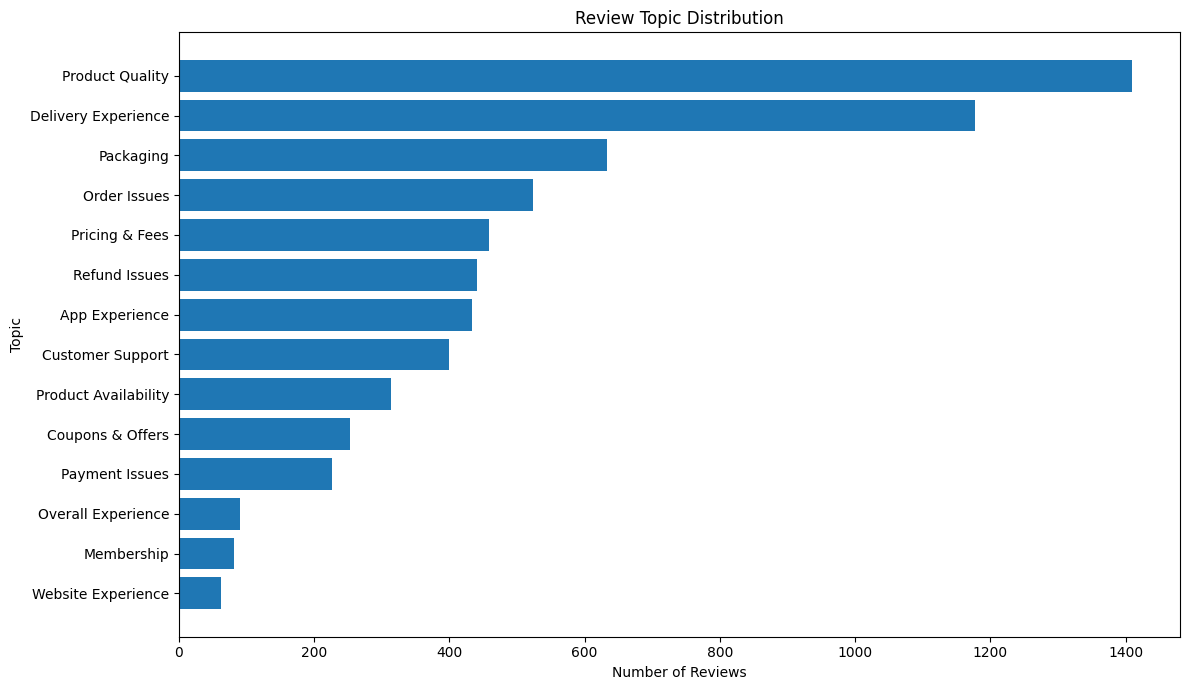


TOPIC SUMMARY
Product Quality: 1410 reviews (21.68%)
Delivery Experience: 1177 reviews (18.1%)
Packaging: 633 reviews (9.73%)
Order Issues: 524 reviews (8.06%)
Pricing & Fees: 459 reviews (7.06%)
Refund Issues: 441 reviews (6.78%)
App Experience: 433 reviews (6.66%)
Customer Support: 399 reviews (6.14%)
Product Availability: 314 reviews (4.83%)
Coupons & Offers: 253 reviews (3.89%)
Payment Issues: 226 reviews (3.48%)
Overall Experience: 90 reviews (1.38%)
Membership: 82 reviews (1.26%)
Website Experience: 62 reviews (0.95%)


In [ ]:
# ============================================================
# NLP ANALYTICS - STEP 2
# TOPIC DISTRIBUTION
# ============================================================


# ------------------------------------------------------------
# 1. TOPIC LABEL MAPPING
# ------------------------------------------------------------

topic_names = {
    0: "Product Quality",
    1: "Delivery Experience",
    2: "Customer Support",
    3: "Order Issues",
    4: "Payment Issues",
    5: "App Experience",
    6: "Website Experience",
    7: "Refund Issues",
    8: "Membership",
    9: "Coupons & Offers",
    10: "Product Availability",
    11: "Packaging",
    12: "Pricing & Fees",
    13: "Overall Experience"
}


# ------------------------------------------------------------
# 2. CHECK TOPIC COLUMN
# ------------------------------------------------------------

print("Dataset Shape:", review.shape)

print("\nTopic column values:")
print(
    review["topic_label"]
    .value_counts(dropna=False)
    .sort_index()
)


# ------------------------------------------------------------
# 3. CREATE TOPIC NAME COLUMN
# ------------------------------------------------------------

review["topic_name"] = review["topic_label"].map(
    topic_names
)


# ------------------------------------------------------------
# 4. COUNT TOPICS
# ------------------------------------------------------------

topic_summary = (
    review["topic_name"]
    .value_counts()
    .reset_index()
)

topic_summary.columns = ["Topic", "Review_Count"]


# ------------------------------------------------------------
# 5. CALCULATE PERCENTAGE
# ------------------------------------------------------------

total_reviews = topic_summary["Review_Count"].sum()

topic_summary["Percentage"] = (
    topic_summary["Review_Count"] / total_reviews * 100
).round(2)


# ------------------------------------------------------------
# 6. DISPLAY SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOPIC DISTRIBUTION")
print("=" * 60)

print("\nTotal Reviews:", total_reviews)

display(topic_summary)


# ------------------------------------------------------------
# 7. BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.barh(
    topic_summary["Topic"][::-1],
    topic_summary["Review_Count"][::-1]
)

plt.title("Review Topic Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. PRINT BUSINESS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOPIC SUMMARY")
print("=" * 60)

for _, row in topic_summary.iterrows():
    print(
        f"{row['Topic']}: "
        f"{row['Review_Count']} reviews "
        f"({row['Percentage']}%)"
    )

SENTIMENT × TOPIC COUNT ANALYSIS


sentiment_name,Negative,Neutral,Positive
topic_name,,,
Product Quality,733,193,484
Delivery Experience,605,180,392
Customer Support,218,57,124
Order Issues,268,82,174
Payment Issues,123,33,70
App Experience,229,52,152
Website Experience,29,12,21
Refund Issues,226,74,141
Membership,40,17,25



SENTIMENT × TOPIC PERCENTAGE


sentiment_name,Negative,Neutral,Positive
topic_name,,,
Product Quality,51.99,13.69,34.33
Delivery Experience,51.40,15.29,33.31
Customer Support,54.64,14.29,31.08
Order Issues,51.15,15.65,33.21
Payment Issues,54.42,14.60,30.97
App Experience,52.89,12.01,35.10
Website Experience,46.77,19.35,33.87
Refund Issues,51.25,16.78,31.97
Membership,48.78,20.73,30.49


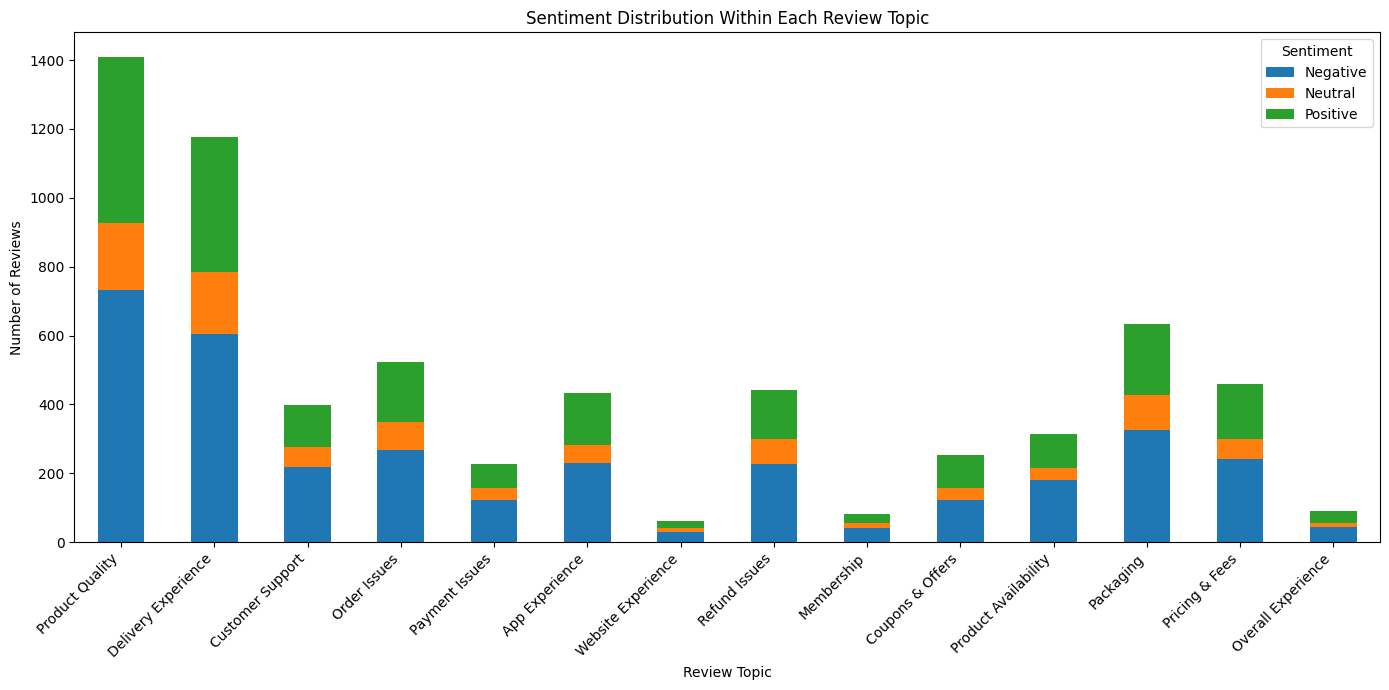


DOMINANT SENTIMENT BY TOPIC


,Topic,Dominant_Sentiment,Review_Count,Percentage_Within_Topic
0,Product Quality,Negative,733,51.99
1,Delivery Experience,Negative,605,51.40
2,Customer Support,Negative,218,54.64
3,Order Issues,Negative,268,51.15
4,Payment Issues,Negative,123,54.42
5,App Experience,Negative,229,52.89
6,Website Experience,Negative,29,46.77
7,Refund Issues,Negative,226,51.25
8,Membership,Negative,40,48.78
9,Coupons & Offers,Negative,123,48.62



SENTIMENT × TOPIC SUMMARY
Product Quality: Negative (733 reviews, 51.99%)
Delivery Experience: Negative (605 reviews, 51.4%)
Customer Support: Negative (218 reviews, 54.64%)
Order Issues: Negative (268 reviews, 51.15%)
Payment Issues: Negative (123 reviews, 54.42%)
App Experience: Negative (229 reviews, 52.89%)
Website Experience: Negative (29 reviews, 46.77%)
Refund Issues: Negative (226 reviews, 51.25%)
Membership: Negative (40 reviews, 48.78%)
Coupons & Offers: Negative (123 reviews, 48.62%)
Product Availability: Negative (181 reviews, 57.64%)
Packaging: Negative (327 reviews, 51.66%)
Pricing & Fees: Negative (241 reviews, 52.51%)
Overall Experience: Negative (44 reviews, 48.89%)


In [ ]:
# ============================================================
# NLP ANALYTICS - STEP 3
# SENTIMENT × TOPIC ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 1. DEFINE ORDER
# ------------------------------------------------------------

sentiment_order = [
    "Negative",
    "Neutral",
    "Positive"
]

topic_order = [
    "Product Quality",
    "Delivery Experience",
    "Customer Support",
    "Order Issues",
    "Payment Issues",
    "App Experience",
    "Website Experience",
    "Refund Issues",
    "Membership",
    "Coupons & Offers",
    "Product Availability",
    "Packaging",
    "Pricing & Fees",
    "Overall Experience"
]


# ------------------------------------------------------------
# 2. CREATE SENTIMENT × TOPIC COUNT MATRIX
# ------------------------------------------------------------

sentiment_topic_counts = pd.crosstab(
    review["topic_name"],
    review["sentiment_name"]
)

# Make sure all sentiment columns exist
sentiment_topic_counts = sentiment_topic_counts.reindex(
    index=topic_order,
    columns=sentiment_order,
    fill_value=0
)


# ------------------------------------------------------------
# 3. DISPLAY COUNT MATRIX
# ------------------------------------------------------------

print("=" * 70)
print("SENTIMENT × TOPIC COUNT ANALYSIS")
print("=" * 70)

display(sentiment_topic_counts)


# ------------------------------------------------------------
# 4. CALCULATE PERCENTAGE WITHIN EACH TOPIC
# ------------------------------------------------------------

sentiment_topic_percentage = (
    sentiment_topic_counts
    .div(sentiment_topic_counts.sum(axis=1), axis=0)
    * 100
).round(2)


print("\n" + "=" * 70)
print("SENTIMENT × TOPIC PERCENTAGE")
print("=" * 70)

display(sentiment_topic_percentage)


# ------------------------------------------------------------
# 5. CREATE STACKED BAR CHART
# ------------------------------------------------------------

ax = sentiment_topic_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Sentiment Distribution Within Each Review Topic")
plt.xlabel("Review Topic")
plt.ylabel("Number of Reviews")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Sentiment"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. FIND DOMINANT SENTIMENT FOR EACH TOPIC
# ------------------------------------------------------------

dominant_sentiment = sentiment_topic_counts.idxmax(axis=1)

dominant_count = sentiment_topic_counts.max(axis=1)

dominant_percentage = (
    dominant_count /
    sentiment_topic_counts.sum(axis=1)
    * 100
).round(2)


topic_sentiment_summary = pd.DataFrame({
    "Topic": sentiment_topic_counts.index,
    "Dominant_Sentiment": dominant_sentiment.values,
    "Review_Count": dominant_count.values,
    "Percentage_Within_Topic": dominant_percentage.values
})


print("\n" + "=" * 70)
print("DOMINANT SENTIMENT BY TOPIC")
print("=" * 70)

display(topic_sentiment_summary)


# ------------------------------------------------------------
# 7. READABLE BUSINESS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SENTIMENT × TOPIC SUMMARY")
print("=" * 70)

for _, row in topic_sentiment_summary.iterrows():

    print(
        f"{row['Topic']}: "
        f"{row['Dominant_Sentiment']} "
        f"({row['Review_Count']} reviews, "
        f"{row['Percentage_Within_Topic']}%)"
    )

#Confidence Analysis

In [ ]:
# ============================================================
# LOAD SAVED NLP MODELS
# ============================================================



# ------------------------------------------------------------
# 1. MODEL PATHS
# ------------------------------------------------------------

SENTIMENT_MODEL_PATH = (
    "/content/drive/MyDrive/Smart_Delivery_Project/"
    "Final_Sentiment_DistilBERT"
)

TOPIC_MODEL_PATH = (
    "/content/drive/MyDrive/Smart_Delivery_Project/"
    "Final_Topic_DistilBERT"
)


# ------------------------------------------------------------
# 2. CHECK MODEL FOLDERS
# ------------------------------------------------------------

print("Sentiment model exists:",
      os.path.exists(SENTIMENT_MODEL_PATH))

print("Topic model exists:",
      os.path.exists(TOPIC_MODEL_PATH))


# ------------------------------------------------------------
# 3. LOAD SENTIMENT MODEL
# ------------------------------------------------------------

sentiment_tokenizer = AutoTokenizer.from_pretrained(
    SENTIMENT_MODEL_PATH,
    local_files_only=True
)

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_MODEL_PATH,
    local_files_only=True
)


# ------------------------------------------------------------
# 4. LOAD TOPIC MODEL
# ------------------------------------------------------------

topic_tokenizer = AutoTokenizer.from_pretrained(
    TOPIC_MODEL_PATH,
    local_files_only=True
)

topic_model = AutoModelForSequenceClassification.from_pretrained(
    TOPIC_MODEL_PATH,
    local_files_only=True
)


# ------------------------------------------------------------
# 5. DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

sentiment_model.to(device)
topic_model.to(device)

sentiment_model.eval()
topic_model.eval()


# ------------------------------------------------------------
# 6. CONFIRM
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NLP MODELS LOADED SUCCESSFULLY")
print("=" * 60)

print("Device:", device)

print(
    "Sentiment model:",
    sentiment_model.config._name_or_path
)

print(
    "Topic model:",
    topic_model.config._name_or_path
)

Sentiment model exists: True
Topic model exists: True


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


NLP MODELS LOADED SUCCESSFULLY
Device: cuda
Sentiment model: /content/drive/MyDrive/Smart_Delivery_Project/Final_Sentiment_DistilBERT
Topic model: /content/drive/MyDrive/Smart_Delivery_Project/Final_Topic_DistilBERT


In [ ]:
print("reviews_df type:", type(review))
print("\nColumns:")
print(review.columns.tolist())

reviews_df type: <class 'pandas.core.frame.DataFrame'>

Columns:
['review_id', 'order_id', 'user_id', 'product_id', 'review_text', 'rating', 'sentiment', 'topic', 'review_date', 'language', 'sentiment_label', 'topic_label', 'sentiment_name', 'topic_name']


In [ ]:
# ============================================================
# STEP 4 — CONFIDENCE ANALYSIS
# ============================================================

import torch
import pandas as pd
from tqdm.auto import tqdm

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

TEXT_COLUMN = "review_text"
BATCH_SIZE = 32
MAX_LENGTH = 128

# ------------------------------------------------------------
# CREATE REVIEW TEXT LIST
# ------------------------------------------------------------

review_texts_for_prediction = (
    review[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

sentiment_predictions = []
sentiment_confidences = []

topic_predictions = []
topic_confidences = []

# ------------------------------------------------------------
# BATCH PREDICTION
# ------------------------------------------------------------

for i in tqdm(
    range(0, len(review_texts_for_prediction), BATCH_SIZE),
    desc="Analyzing reviews"
):

    batch_reviews = review_texts_for_prediction[
        i:i + BATCH_SIZE
    ]

    # ========================================================
    # SENTIMENT PREDICTION
    # ========================================================

    sentiment_inputs = sentiment_tokenizer(
        batch_reviews,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    sentiment_inputs = {
        key: value.to(device)
        for key, value in sentiment_inputs.items()
    }

    with torch.no_grad():
        sentiment_output = sentiment_model(
            **sentiment_inputs
        )

    sentiment_probs = torch.softmax(
        sentiment_output.logits,
        dim=1
    )

    sentiment_conf, sentiment_pred = torch.max(
        sentiment_probs,
        dim=1
    )

    sentiment_predictions.extend(
        sentiment_pred.cpu().numpy().tolist()
    )

    sentiment_confidences.extend(
        sentiment_conf.cpu().numpy().tolist()
    )

    # ========================================================
    # TOPIC PREDICTION
    # ========================================================

    topic_inputs = topic_tokenizer(
        batch_reviews,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    topic_inputs = {
        key: value.to(device)
        for key, value in topic_inputs.items()
    }

    with torch.no_grad():
        topic_output = topic_model(
            **topic_inputs
        )

    topic_probs = torch.softmax(
        topic_output.logits,
        dim=1
    )

    topic_conf, topic_pred = torch.max(
        topic_probs,
        dim=1
    )

    topic_predictions.extend(
        topic_pred.cpu().numpy().tolist()
    )

    topic_confidences.extend(
        topic_conf.cpu().numpy().tolist()
    )


# ============================================================
# ADD PREDICTIONS TO DATAFRAME
# ============================================================

review["predicted_sentiment_label"] = sentiment_predictions

review["predicted_sentiment"] = (
    review["predicted_sentiment_label"]
    .map(sentiment_names)
)

review["sentiment_confidence"] = sentiment_confidences


review["predicted_topic_label"] = topic_predictions

review["predicted_topic"] = (
    review["predicted_topic_label"]
    .map(topic_names)
)

review["topic_confidence"] = topic_confidences


# ============================================================
# CONFIDENCE LEVEL
# ============================================================

def confidence_level(value):

    if value >= 0.90:
        return "High"
    elif value >= 0.70:
        return "Medium"
    else:
        return "Low"


review["sentiment_confidence_level"] = (
    review["sentiment_confidence"]
    .apply(confidence_level)
)

review["topic_confidence_level"] = (
    review["topic_confidence"]
    .apply(confidence_level)
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("CONFIDENCE ANALYSIS COMPLETED")
print("=" * 70)

print("\nTotal reviews analyzed:", len(review))

print("\nSentiment Confidence:")
print(
    review["sentiment_confidence"].describe()
)

print("\nTopic Confidence:")
print(
    review["topic_confidence"].describe()
)

print("\nSentiment Confidence Levels:")
print(
    review["sentiment_confidence_level"].value_counts()
)

print("\nTopic Confidence Levels:")
print(
    review["topic_confidence_level"].value_counts()
)

Analyzing reviews:   0%|          | 0/204 [00:00<?, ?it/s]

CONFIDENCE ANALYSIS COMPLETED

Total reviews analyzed: 6503

Sentiment Confidence:
count    6503.000000
mean        0.997697
std         0.007357
min         0.547260
25%         0.997980
50%         0.998296
75%         0.998502
max         0.998632
Name: sentiment_confidence, dtype: float64

Topic Confidence:
count    6503.000000
mean        0.991362
std         0.017286
min         0.247148
25%         0.991635
50%         0.992992
75%         0.996904
max         0.997741
Name: topic_confidence, dtype: float64

Sentiment Confidence Levels:
sentiment_confidence_level
High      6499
Medium       3
Low          1
Name: count, dtype: int64

Topic Confidence Levels:
topic_confidence_level
High      6497
Low          3
Medium       3
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 5 — LOW CONFIDENCE REVIEW ANALYSIS
# ============================================================

# ------------------------------------------------------------
# SENTIMENT: LOW CONFIDENCE REVIEWS
# ------------------------------------------------------------

low_sentiment = review[
    review["sentiment_confidence"] < 0.70
].copy()

print("=" * 70)
print("LOW CONFIDENCE SENTIMENT REVIEWS")
print("=" * 70)

print("\nCount:", len(low_sentiment))

if len(low_sentiment) > 0:
    print(
        low_sentiment[
            [
                "review_text",
                "sentiment",
                "predicted_sentiment",
                "sentiment_confidence"
            ]
        ].to_string(index=False)
    )
else:
    print("No low-confidence sentiment reviews found.")


# ------------------------------------------------------------
# TOPIC: LOW CONFIDENCE REVIEWS
# ------------------------------------------------------------

low_topic = review[
    review["topic_confidence"] < 0.70
].copy()

print("\n" + "=" * 70)
print("LOW CONFIDENCE TOPIC REVIEWS")
print("=" * 70)

print("\nCount:", len(low_topic))

if len(low_topic) > 0:
    print(
        low_topic[
            [
                "review_text",
                "topic",
                "predicted_topic",
                "topic_confidence"
            ]
        ].to_string(index=False)
    )
else:
    print("No low-confidence topic reviews found.")

LOW CONFIDENCE SENTIMENT REVIEWS

Count: 1
                                                    review_text sentiment predicted_sentiment  sentiment_confidence
hi customer care resppponded, waiting for update kindly resolve   neutral             Neutral               0.54726

LOW CONFIDENCE TOPIC REVIEWS

Count: 3
                                            review_text   topic    predicted_topic  topic_confidence
                hi no comments :) call me on 9876536041  others Overall Experience          0.532342
                                   as usual it was fine  others Overall Experience          0.343133
hi lady finger was okay, nothing special visit for more product Overall Experience          0.247148


#Prediction vs Actual Label Validation


In [ ]:
# ============================================================
# STEP 6 — PREDICTION VS ACTUAL LABEL VALIDATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pandas as pd


# ============================================================
# SENTIMENT VALIDATION
# ============================================================

sentiment_actual = review["sentiment_label"]
sentiment_predicted = review["predicted_sentiment_label"]


sentiment_accuracy = accuracy_score(
    sentiment_actual,
    sentiment_predicted
)


print("=" * 70)
print("SENTIMENT MODEL VALIDATION")
print("=" * 70)

print(
    f"\nSentiment Accuracy: "
    f"{sentiment_accuracy:.4f}"
)

print(
    f"Sentiment Accuracy (%): "
    f"{sentiment_accuracy * 100:.2f}%"
)


print("\nSentiment Classification Report:")

print(
    classification_report(
        sentiment_actual,
        sentiment_predicted,
        target_names=[
            sentiment_names[0],
            sentiment_names[1],
            sentiment_names[2]
        ],
        digits=4
    )
)


# ============================================================
# SENTIMENT CONFUSION MATRIX
# ============================================================

sentiment_cm = confusion_matrix(
    sentiment_actual,
    sentiment_predicted
)

print("\nSentiment Confusion Matrix:")

print(
    pd.DataFrame(
        sentiment_cm,
        index=[
            "Actual Negative",
            "Actual Neutral",
            "Actual Positive"
        ],
        columns=[
            "Predicted Negative",
            "Predicted Neutral",
            "Predicted Positive"
        ]
    )
)


# ============================================================
# TOPIC VALIDATION
# ============================================================

topic_actual = review["topic_label"]
topic_predicted = review["predicted_topic_label"]


topic_accuracy = accuracy_score(
    topic_actual,
    topic_predicted
)


print("\n" + "=" * 70)
print("TOPIC MODEL VALIDATION")
print("=" * 70)

print(
    f"\nTopic Accuracy: "
    f"{topic_accuracy:.4f}"
)

print(
    f"Topic Accuracy (%): "
    f"{topic_accuracy * 100:.2f}%"
)


# ============================================================
# TOPIC CLASSIFICATION REPORT
# ============================================================

topic_class_ids = sorted(
    review["topic_label"].unique()
)

topic_target_names = [
    topic_names[i]
    for i in topic_class_ids
]


print("\nTopic Classification Report:")

print(
    classification_report(
        topic_actual,
        topic_predicted,
        labels=topic_class_ids,
        target_names=topic_target_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# TOPIC CONFUSION MATRIX
# ============================================================

topic_cm = confusion_matrix(
    topic_actual,
    topic_predicted,
    labels=topic_class_ids
)

print("\nTopic Confusion Matrix:")

print(
    pd.DataFrame(
        topic_cm,
        index=[
            f"Actual: {topic_names[i]}"
            for i in topic_class_ids
        ],
        columns=[
            f"Predicted: {topic_names[i]}"
            for i in topic_class_ids
        ]
    )
)

SENTIMENT MODEL VALIDATION

Sentiment Accuracy: 1.0000
Sentiment Accuracy (%): 100.00%

Sentiment Classification Report:
              precision    recall  f1-score   support

    Negative     1.0000    1.0000    1.0000      3387
     Neutral     1.0000    1.0000    1.0000       943
    Positive     1.0000    1.0000    1.0000      2173

    accuracy                         1.0000      6503
   macro avg     1.0000    1.0000    1.0000      6503
weighted avg     1.0000    1.0000    1.0000      6503


Sentiment Confusion Matrix:
                 Predicted Negative  Predicted Neutral  Predicted Positive
Actual Negative                3387                  0                   0
Actual Neutral                    0                943                   0
Actual Positive                   0                  0                2173

TOPIC MODEL VALIDATION

Topic Accuracy: 0.9997
Topic Accuracy (%): 99.97%

Topic Classification Report:
                      precision    recall  f1-score   support

 

In [ ]:
# ============================================================
# STEP 7 — TOPIC PREDICTION MISMATCH ANALYSIS
# ============================================================

topic_mismatches = review[
    review["topic_label"] != review["predicted_topic_label"]
].copy()

print("=" * 70)
print("TOPIC PREDICTION MISMATCHES")
print("=" * 70)

print("\nTotal mismatches:", len(topic_mismatches))

if len(topic_mismatches) > 0:

    print("\nMismatch details:\n")

    print(
        topic_mismatches[
            [
                "review_text",
                "topic",
                "predicted_topic",
                "topic_confidence"
            ]
        ].to_string(index=False)
    )

else:
    print("\nNo topic prediction mismatches found.")

TOPIC PREDICTION MISMATCHES

Total mismatches: 2

Mismatch details:

                                              review_text   topic     predicted_topic  topic_confidence
guys deliverly chaarge romba adhigam today kindly resolve pricing Delivery Experience          0.969882
  hi lady finger was okay, nothing special visit for more product  Overall Experience          0.247148


In [ ]:
# ============================================================
# STEP 8 — VERIFY TOPIC LABEL MISMATCHES
# ============================================================

print("=" * 70)
print("VERIFYING TOPIC LABELS")
print("=" * 70)

print(
    topic_mismatches[
        [
            "review_text",
            "topic",
            "topic_label",
            "predicted_topic",
            "predicted_topic_label",
            "topic_confidence"
        ]
    ].to_string(index=False)
)

print("\nTopic mapping:")
for label, name in topic_names.items():
    print(f"{label} -> {name}")

VERIFYING TOPIC LABELS
                                              review_text   topic  topic_label     predicted_topic  predicted_topic_label  topic_confidence
guys deliverly chaarge romba adhigam today kindly resolve pricing           12 Delivery Experience                      1          0.969882
  hi lady finger was okay, nothing special visit for more product            0  Overall Experience                     13          0.247148

Topic mapping:
0 -> Product Quality
1 -> Delivery Experience
2 -> Customer Support
3 -> Order Issues
4 -> Payment Issues
5 -> App Experience
6 -> Website Experience
7 -> Refund Issues
8 -> Membership
9 -> Coupons & Offers
10 -> Product Availability
11 -> Packaging
12 -> Pricing & Fees
13 -> Overall Experience


In [ ]:
# ============================================================
# STEP 9 — CHECK TOPIC LABEL CONSISTENCY
# ============================================================

# Create expected topic name from the numeric label
review["expected_topic_name"] = (
    review["topic_label"].map(topic_names)
)

# Find rows where the original topic text
# does not match the numeric topic label
topic_label_issues = review[
    review["topic"].astype(str).str.strip()
    != review["expected_topic_name"].astype(str).str.strip()
].copy()

print("=" * 70)
print("TOPIC LABEL CONSISTENCY CHECK")
print("=" * 70)

print("\nTotal reviews:", len(review))

print(
    "Topic label inconsistencies:",
    len(topic_label_issues)
)

if len(topic_label_issues) > 0:

    print("\nInconsistent rows:\n")

    print(
        topic_label_issues[
            [
                "review_text",
                "topic",
                "topic_label",
                "expected_topic_name"
            ]
        ].to_string(index=False)
    )

else:
    print("\nNo topic label inconsistencies found.")

print("\n" + "=" * 70)

Streaming output truncated to the last 5000 lines.
                                                         hi refnd rejected without any proper explanation do something about it           refund            7        Refund Issues
                                                         honestly entire order was correct and well packed pls look into this 😍            order            3         Order Issues
                                                                       delivery person could not find the address and cancelled         delivery            1  Delivery Experience
                                                                                             team app works, sometimes slow ...              app            5       App Experience
                                                                      hi super fast delivery even in the rain !! visit for more         delivery            1  Delivery Experience
                                                      

In [ ]:
# ============================================================
# STEP 9 — CLEAN TOPIC CONSISTENCY CHECK
# ============================================================

# Create expected topic name from topic_label
review["expected_topic_name"] = (
    review["topic_label"].map(topic_names)
)

# Normalize both columns before comparison
actual_topic_clean = (
    review["topic"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

expected_topic_clean = (
    review["expected_topic_name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Find genuine mismatches
topic_label_issues = review[
    actual_topic_clean != expected_topic_clean
].copy()

print("=" * 70)
print("CLEAN TOPIC LABEL CONSISTENCY CHECK")
print("=" * 70)

print("\nTotal reviews:", len(review))

print(
    "Genuine topic inconsistencies:",
    len(topic_label_issues)
)

if len(topic_label_issues) > 0:

    print("\nGenuine inconsistent rows:\n")

    print(
        topic_label_issues[
            [
                "review_text",
                "topic",
                "topic_label",
                "expected_topic_name"
            ]
        ].to_string(index=False)
    )

else:
    print("\n✅ No topic label inconsistencies found.")

print("\n" + "=" * 70)

CLEAN TOPIC LABEL CONSISTENCY CHECK

Total reviews: 6503
Genuine topic inconsistencies: 5788

Genuine inconsistent rows:

                                                                                                                    review_text            topic  topic_label  expected_topic_name
                                           seriously support agent was useless and kept repeating the same thing visit for more customer_support            2     Customer Support
                                   coca cola coca cola expiry date already over, how can you send this do something about it !!          product            0      Product Quality
                                                           honestly order got cancelled automatically without any reason thanks            order            3         Order Issues
                                                                                     the grapes green was stale and smelled bad          product            0     

In [ ]:
# ============================================================
# STEP 9 — RESET TOPIC MAPPING
# ============================================================

# Recreate topic name directly from the numeric label
review["topic_name"] = review["topic_label"].map(topic_names)

# Count rows where topic label and mapped name agree
mapping_check = (
    review["topic_name"].notna()
)

print("=" * 70)
print("TOPIC MAPPING CHECK")
print("=" * 70)

print("\nTotal reviews:", len(review))
print("Valid topic labels:", mapping_check.sum())
print("Invalid topic labels:", (~mapping_check).sum())

print("\nTopic label distribution:")
print(
    review["topic_label"]
    .value_counts()
    .sort_index()
)

print("\nTopic mapping:")
for label, name in topic_names.items():
    print(f"{label:2d} -> {name}")

print("\n✅ Topic mapping is ready for analytics.")

TOPIC MAPPING CHECK

Total reviews: 6503
Valid topic labels: 6503
Invalid topic labels: 0

Topic label distribution:
topic_label
0     1410
1     1177
2      399
3      524
4      226
5      433
6       62
7      441
8       82
9      253
10     314
11     633
12     459
13      90
Name: count, dtype: int64

Topic mapping:
 0 -> Product Quality
 1 -> Delivery Experience
 2 -> Customer Support
 3 -> Order Issues
 4 -> Payment Issues
 5 -> App Experience
 6 -> Website Experience
 7 -> Refund Issues
 8 -> Membership
 9 -> Coupons & Offers
10 -> Product Availability
11 -> Packaging
12 -> Pricing & Fees
13 -> Overall Experience

✅ Topic mapping is ready for analytics.


In [ ]:
#Create NLP KPI Summary
# ============================================================
# STEP 10 — NLP KPI SUMMARY
# ============================================================

print("=" * 70)
print("SMART DELIVERY — REVIEW ANALYTICS KPI SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# BASIC COUNTS
# ------------------------------------------------------------

total_reviews = len(review)

negative_reviews = (
    review["sentiment_label"] == 0
).sum()

neutral_reviews = (
    review["sentiment_label"] == 1
).sum()

positive_reviews = (
    review["sentiment_label"] == 2
).sum()


# ------------------------------------------------------------
# PERCENTAGES
# ------------------------------------------------------------

negative_pct = (
    negative_reviews / total_reviews * 100
)

neutral_pct = (
    neutral_reviews / total_reviews * 100
)

positive_pct = (
    positive_reviews / total_reviews * 100
)


# ------------------------------------------------------------
# TOPIC
# ------------------------------------------------------------

top_topic = (
    review["topic_name"]
    .value_counts()
    .idxmax()
)

top_topic_count = (
    review["topic_name"]
    .value_counts()
    .max()
)

top_topic_pct = (
    top_topic_count / total_reviews * 100
)


# ------------------------------------------------------------
# CONFIDENCE
# ------------------------------------------------------------

avg_sentiment_confidence = (
    review["sentiment_confidence"].mean() * 100
)

avg_topic_confidence = (
    review["topic_confidence"].mean() * 100
)


# ------------------------------------------------------------
# PRINT KPI RESULTS
# ------------------------------------------------------------

print(f"\nTotal Reviews              : {total_reviews:,}")

print(
    f"Negative Reviews           : "
    f"{negative_reviews:,} ({negative_pct:.2f}%)"
)

print(
    f"Neutral Reviews            : "
    f"{neutral_reviews:,} ({neutral_pct:.2f}%)"
)

print(
    f"Positive Reviews           : "
    f"{positive_reviews:,} ({positive_pct:.2f}%)"
)

print(
    f"\nMost Common Topic          : "
    f"{top_topic}"
)

print(
    f"Most Common Topic Count    : "
    f"{top_topic_count:,}"
)

print(
    f"Most Common Topic %        : "
    f"{top_topic_pct:.2f}%"
)

print(
    f"\nAverage Sentiment Confidence: "
    f"{avg_sentiment_confidence:.2f}%"
)

print(
    f"Average Topic Confidence    : "
    f"{avg_topic_confidence:.2f}%"
)

print("\n" + "=" * 70)
print("KPI SUMMARY COMPLETED")
print("=" * 70)

SMART DELIVERY — REVIEW ANALYTICS KPI SUMMARY

Total Reviews              : 6,503
Negative Reviews           : 3,387 (52.08%)
Neutral Reviews            : 943 (14.50%)
Positive Reviews           : 2,173 (33.42%)

Most Common Topic          : Product Quality
Most Common Topic Count    : 1,410
Most Common Topic %        : 21.68%

Average Sentiment Confidence: 99.77%
Average Topic Confidence    : 99.14%

KPI SUMMARY COMPLETED


In [ ]:
# ============================================================
# STEP 11 — TOPIC-WISE SENTIMENT ANALYSIS
# ============================================================

topic_sentiment = pd.crosstab(
    review["topic_name"],
    review["sentiment_name"]
)

# Ensure all sentiment columns exist
for sentiment in ["Negative", "Neutral", "Positive"]:
    if sentiment not in topic_sentiment.columns:
        topic_sentiment[sentiment] = 0

# Correct column order
topic_sentiment = topic_sentiment[
    ["Negative", "Neutral", "Positive"]
]

# ------------------------------------------------------------
# ADD TOTAL AND PERCENTAGES
# ------------------------------------------------------------

topic_sentiment["Total"] = (
    topic_sentiment[
        ["Negative", "Neutral", "Positive"]
    ].sum(axis=1)
)

topic_sentiment["Negative %"] = (
    topic_sentiment["Negative"]
    / topic_sentiment["Total"]
    * 100
)

topic_sentiment["Neutral %"] = (
    topic_sentiment["Neutral"]
    / topic_sentiment["Total"]
    * 100
)

topic_sentiment["Positive %"] = (
    topic_sentiment["Positive"]
    / topic_sentiment["Total"]
    * 100
)

# ------------------------------------------------------------
# SORT BY NEGATIVE PERCENTAGE
# ------------------------------------------------------------

topic_sentiment_sorted = (
    topic_sentiment
    .sort_values(
        "Negative %",
        ascending=False
    )
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 90)
print("TOPIC-WISE SENTIMENT ANALYSIS")
print("=" * 90)

print(
    topic_sentiment_sorted.to_string(
        formatters={
            "Negative %": "{:.2f}%".format,
            "Neutral %": "{:.2f}%".format,
            "Positive %": "{:.2f}%".format
        }
    )
)

print("\n" + "=" * 90)

TOPIC-WISE SENTIMENT ANALYSIS
sentiment_name        Negative  Neutral  Positive  Total Negative % Neutral % Positive %
topic_name                                                                              
Product Availability       181       35        98    314     57.64%    11.15%     31.21%
Customer Support           218       57       124    399     54.64%    14.29%     31.08%
Payment Issues             123       33        70    226     54.42%    14.60%     30.97%
App Experience             229       52       152    433     52.89%    12.01%     35.10%
Pricing & Fees             241       60       158    459     52.51%    13.07%     34.42%
Product Quality            733      193       484   1410     51.99%    13.69%     34.33%
Packaging                  327      100       206    633     51.66%    15.80%     32.54%
Delivery Experience        605      180       392   1177     51.40%    15.29%     33.31%
Refund Issues              226       74       141    441     51.25%    16.78%   

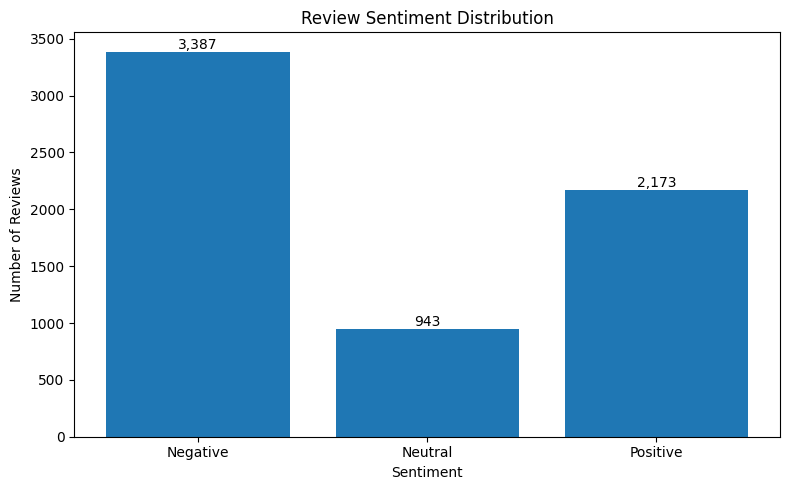

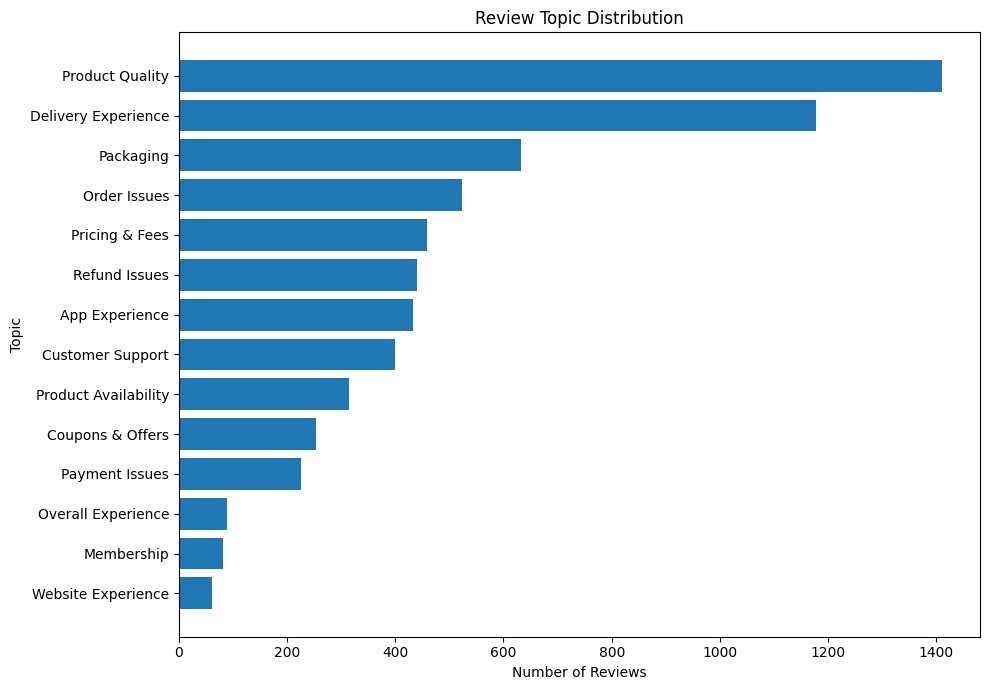

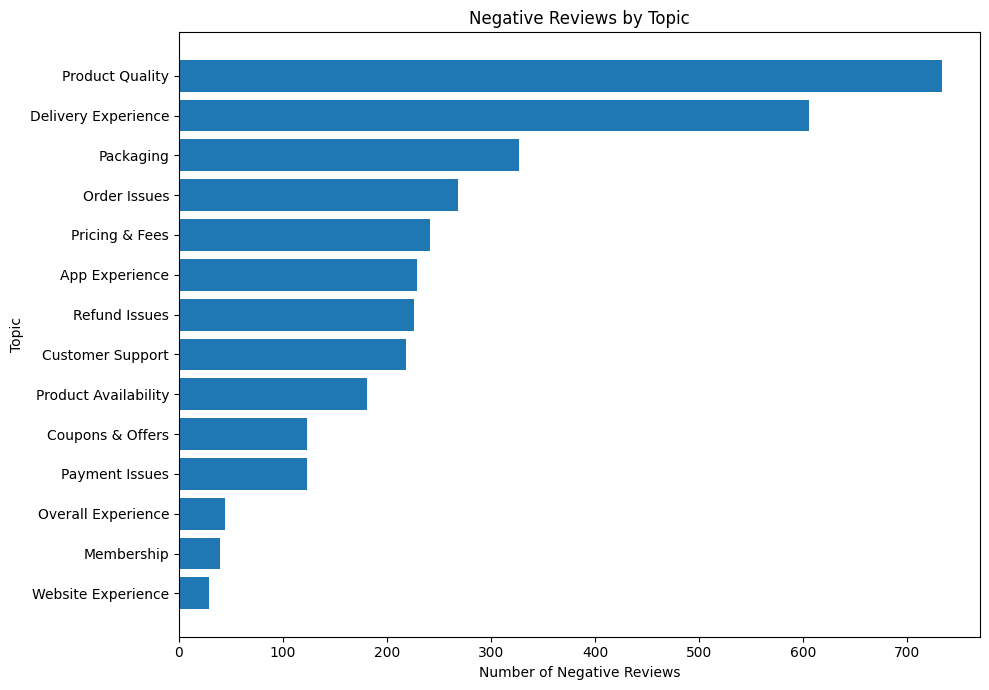

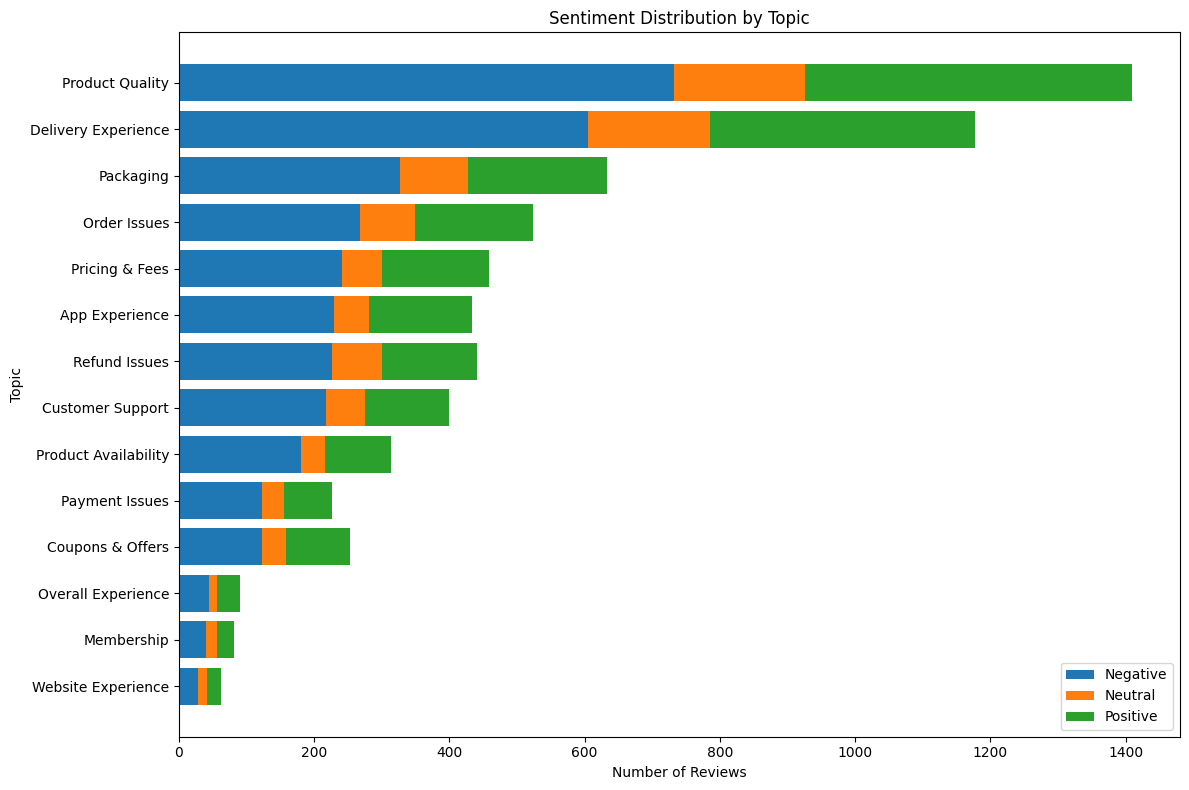

NLP VISUALIZATIONS COMPLETED


In [ ]:
# ============================================================
# STEP 12 — NLP VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# CHART 1 — SENTIMENT DISTRIBUTION
# ============================================================

sentiment_counts = (
    review["sentiment_name"]
    .value_counts()
    .reindex(
        ["Negative", "Neutral", "Positive"]
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, value in enumerate(sentiment_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# CHART 2 — TOPIC DISTRIBUTION
# ============================================================

topic_counts = (
    review["topic_name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    topic_counts.index,
    topic_counts.values
)

plt.title("Review Topic Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()


# ============================================================
# CHART 3 — NEGATIVE REVIEWS BY TOPIC
# ============================================================

negative_by_topic = (
    review[
        review["sentiment_name"] == "Negative"
    ]["topic_name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    negative_by_topic.index,
    negative_by_topic.values
)

plt.title("Negative Reviews by Topic")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()


# ============================================================
# CHART 4 — SENTIMENT BY TOPIC
# ============================================================

sentiment_by_topic = (
    pd.crosstab(
        review["topic_name"],
        review["sentiment_name"]
    )
    .reindex(
        columns=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        fill_value=0
    )
)

sentiment_by_topic = (
    sentiment_by_topic
    .sort_values(
        "Negative",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    sentiment_by_topic.index,
    sentiment_by_topic["Negative"],
    label="Negative"
)

plt.barh(
    sentiment_by_topic.index,
    sentiment_by_topic["Neutral"],
    left=sentiment_by_topic["Negative"],
    label="Neutral"
)

plt.barh(
    sentiment_by_topic.index,
    sentiment_by_topic["Positive"],
    left=(
        sentiment_by_topic["Negative"]
        + sentiment_by_topic["Neutral"]
    ),
    label="Positive"
)

plt.title("Sentiment Distribution by Topic")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic")
plt.legend()

plt.tight_layout()
plt.show()


print("=" * 70)
print("NLP VISUALIZATIONS COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# STEP 13 — SAVE NLP PREDICTION RESULTS
# ============================================================

import os

# ------------------------------------------------------------
# SAVE LOCATION
# ------------------------------------------------------------

NLP_OUTPUT_PATH = (
    "/content/drive/MyDrive/Smart_Delivery_Project/"
    "NLP_Review_Analysis.csv"
)

# ------------------------------------------------------------
# COLUMNS TO SAVE
# ------------------------------------------------------------

nlp_columns = [
    "review_id",
    "order_id",
    "user_id",
    "product_id",
    "review_text",
    "rating",
    "sentiment",
    "topic",
    "review_date",
    "language",
    "sentiment_label",
    "topic_label",
    "sentiment_name",
    "topic_name",
    "predicted_sentiment_label",
    "predicted_sentiment",
    "sentiment_confidence",
    "sentiment_confidence_level",
    "predicted_topic_label",
    "predicted_topic",
    "topic_confidence",
    "topic_confidence_level"
]

# Keep only columns that currently exist
nlp_columns = [
    col for col in nlp_columns
    if col in review.columns
]

# ------------------------------------------------------------
# CREATE OUTPUT DATAFRAME
# ------------------------------------------------------------

nlp_results = review[nlp_columns].copy()

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

nlp_results.to_csv(
    NLP_OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# VERIFY FILE
# ------------------------------------------------------------

print("=" * 70)
print("NLP RESULTS SAVED SUCCESSFULLY")
print("=" * 70)

print("\nFile:")
print(NLP_OUTPUT_PATH)

print("\nRows saved:", len(nlp_results))

print("\nColumns saved:")
print(nlp_results.columns.tolist())

print(
    "\nFile exists:",
    os.path.exists(NLP_OUTPUT_PATH)
)

print("\nFile size:")
print(
    round(
        os.path.getsize(NLP_OUTPUT_PATH) / (1024 * 1024),
        2
    ),
    "MB"
)

print("\n" + "=" * 70)

NLP RESULTS SAVED SUCCESSFULLY

File:
/content/drive/MyDrive/Smart_Delivery_Project/NLP_Review_Analysis.csv

Rows saved: 6503

Columns saved:
['review_id', 'order_id', 'user_id', 'product_id', 'review_text', 'rating', 'sentiment', 'topic', 'review_date', 'language', 'sentiment_label', 'topic_label', 'sentiment_name', 'topic_name', 'predicted_sentiment_label', 'predicted_sentiment', 'sentiment_confidence', 'sentiment_confidence_level', 'predicted_topic_label', 'predicted_topic', 'topic_confidence', 'topic_confidence_level']

File exists: True

File size:
1.49 MB

